In [35]:
# Import pustaka yang dibutuhkan
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import os
# Load dataset (gunakan kolom 'ulasan' sebagai teks)
df = pd.read_csv('dataset/sentiment-ML.csv')
# Tampilkan informasi awal
df.info()
df.head()

# ===== Preprocessing & Heuristic Labeling (offline) =====
import re
import nltk
nltk.download('punkt', quiet=True)
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
factory = StemmerFactory()
stemmer = factory.create_stemmer()
remover = StopWordRemoverFactory().create_stop_word_remover()

def clean_text(text):
    if pd.isna(text):
        return ''
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', ' ', text)
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    text = re.sub(r'\d+', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def preprocess_ind(text):
    # Step 1: Clean text
    cleaned = clean_text(text)
    
    # Step 2: Stopword removal (Sastrawi)
    text_after_stopword = remover.remove(cleaned)
    
    # Step 3: Tokenization
    tokens = nltk.word_tokenize(text_after_stopword)
    
    # Step 4: Stemming
    stemmed = ' '.join([stemmer.stem(t) for t in tokens])
    
    return cleaned, text_after_stopword, stemmed

# Apply cleaning + stopword removal + stemming to 'ulasan' column
if 'ulasan' in df.columns:
    df['clean_text'] = df['ulasan'].apply(clean_text)
    # Apply preprocessing dengan 3 tahap: clean -> stopword -> stem
    preprocessing_result = df['clean_text'].apply(lambda x: pd.Series([preprocess_ind(x)[1], preprocess_ind(x)[2]]))
    df['stopword_removed'] = preprocessing_result[0]
    df['processed_text'] = preprocessing_result[1]
    df['stemming_data'] = df['processed_text']
else:
    raise ValueError("Kolom 'ulasan' tidak ditemukan di dataset. Pastikan file dataset berisi kolom 'ulasan'.")

# Display contoh Before-After Preprocessing
print("\n=== CONTOH PREPROCESSING: BEFORE vs AFTER ===")
for idx in range(min(3, len(df))):
    print(f"\n--- Contoh {idx+1} ---")
    print(f"ORIGINAL: {df['ulasan'].iloc[idx][:150]}...")
    print(f"AFTER CLEANING: {df['clean_text'].iloc[idx][:150]}...")
    print(f"AFTER STOPWORD REMOVAL: {df['stopword_removed'].iloc[idx][:150]}...")
    print(f"FINAL (STEMMED): {df['stemming_data'].iloc[idx][:150]}...")

# If Sentiment column missing, apply a simple lexicon-based heuristic
if 'Sentiment' not in df.columns or df['Sentiment'].isnull().all():
    pos_keywords = ['bagus','suka','mantap','keren','baik','terima kasih','love','recommended','oke','happy']
    neg_keywords = ['lag','ngelag','bug','jelek','buruk','rusak','kecewa','force close','stuck','freeze','lemot','error','nge lag']
    def heuristic_label(text):
        t = ' ' + (text or '') + ' '
        pos = sum(t.count(k) for k in pos_keywords)
        neg = sum(t.count(k) for k in neg_keywords)
        if pos > neg:
            return 'Positif'
        if neg > pos:
            return 'Negatif'
        return 'Netral'
    df['Sentiment'] = df['clean_text'].apply(heuristic_label)

# Create output folder and save preprocessing snapshots
os.makedirs('preprocessing_stages', exist_ok=True)
df[['ulasan','clean_text','stopword_removed','processed_text','stemming_data','Sentiment']].to_csv('preprocessing_stages/03_full_preprocessing.csv', index=False)
df[['ulasan','clean_text']].to_csv('preprocessing_stages/01_clean_text.csv', index=False)
df[['ulasan','stopword_removed','processed_text','stemming_data']].to_csv('preprocessing_stages/02_stemmed_text.csv', index=False)
df[['ulasan','Sentiment']].to_csv('preprocessing_stages/04_labeled_data.csv', index=False)
print('\n✅ Preprocessing and heuristic labeling done. Files saved to preprocessing_stages/')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1682 entries, 0 to 1681
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   url        1682 non-null   object
 1   user       1682 non-null   object
 2   data       1682 non-null   object
 3   ulasan     1682 non-null   object
 4   tanggapan  1055 non-null   object
 5   histori    745 non-null    object
dtypes: object(6)
memory usage: 79.0+ KB

=== CONTOH PREPROCESSING: BEFORE vs AFTER ===

--- Contoh 1 ---
ORIGINAL: Kasih tim yg bener lah, masa 10 game ga pernah dapat tim yg bagus, trus kalau ada yg mainnya kayak bot habisin aja kredit score nya biar ga bisa main ...
AFTER CLEANING: kasih tim yg bener lah masa game ga pernah dapat tim yg bagus trus kalau ada yg mainnya kayak bot habisin aja kredit score nya biar ga bisa main rank ...
AFTER STOPWORD REMOVAL: kasih tim yg bener lah masa game ga pernah tim yg bagus trus kalau yg mainnya kayak bot habisin aja kredit score nya b

In [36]:
!pip install Sastrawi scikit-learn pandas matplotlib seaborn wordcloud nltk --quiet

C:\Users\rafly\AppData\Local\Temp\ipykernel_21088\3571354890.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=sentiment_count.index, y=sentiment_count.values, palette='pastel')


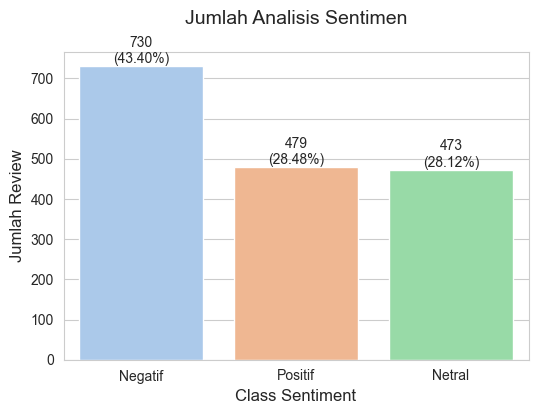

In [37]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Count by Sentiment (ensure column exists)
sentiment_count = df['Sentiment'].value_counts()
sns.set_style('whitegrid')
fig, ax = plt.subplots(figsize=(6, 4))
ax = sns.barplot(x=sentiment_count.index, y=sentiment_count.values, palette='pastel')
plt.title('Jumlah Analisis Sentimen', fontsize=14, pad=20)
plt.xlabel('Class Sentiment', fontsize=12)
plt.ylabel('Jumlah Review', fontsize=12)
total = sentiment_count.sum()
for i, count in enumerate(sentiment_count.values):
    percentage = f'{100 * count / total:.2f}%'
    ax.text(i, count + 0.10, f'{count}\n({percentage})', ha='center', va='bottom')
plt.show()

In [38]:
# Load data dengan stemming_data dan sentiment (dari preprocessing cell sebelumnya)
# Jika notebook dijalankan dari awal, df sudah tersedia dengan kolom stemming_data
# Jika tidak, load dari file preprocessing lengkap
if 'stemming_data' not in df.columns:
    df = pd.read_csv('preprocessing_stages/03_full_preprocessing.csv')

# Tampilkan informasi awal
df.info()
df.head()
print(f"\nDataset shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1682 entries, 0 to 1681
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   url               1682 non-null   object
 1   user              1682 non-null   object
 2   data              1682 non-null   object
 3   ulasan            1682 non-null   object
 4   tanggapan         1055 non-null   object
 5   histori           745 non-null    object
 6   clean_text        1682 non-null   object
 7   stopword_removed  1682 non-null   object
 8   processed_text    1682 non-null   object
 9   stemming_data     1682 non-null   object
 10  Sentiment         1682 non-null   object
dtypes: object(11)
memory usage: 144.7+ KB

Dataset shape: (1682, 11)
Columns: ['url', 'user', 'data', 'ulasan', 'tanggapan', 'histori', 'clean_text', 'stopword_removed', 'processed_text', 'stemming_data', 'Sentiment']


In [39]:
df['Sentiment'].value_counts()

Sentiment
Negatif    730
Positif    479
Netral     473
Name: count, dtype: int64

Jumlah data latih: 1345
Jumlah data uji: 337


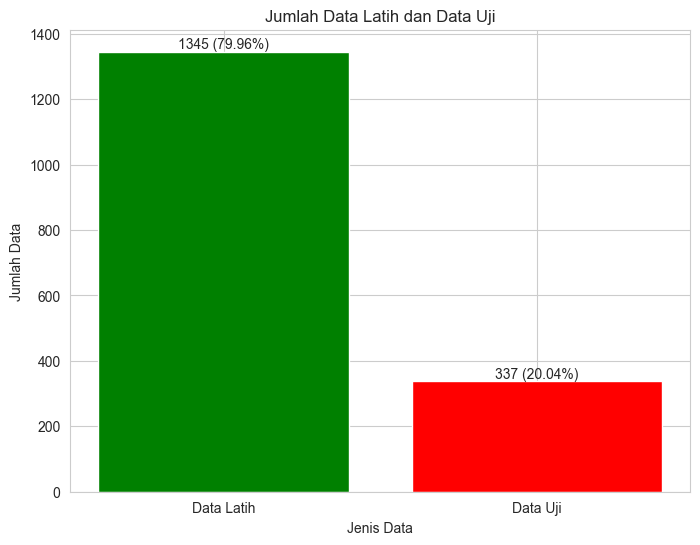

In [40]:
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# Membagi data menjadi data pelatihan dan pengujian
X_train, X_test, y_train, y_test = train_test_split(
    df['stemming_data'], df['Sentiment'], test_size=0.2, random_state=42)

# Buat folder jika belum ada
import os
os.makedirs('svm', exist_ok=True)

# Simpan data latih ke file
train_data = pd.DataFrame({'text': X_train, 'sentiment': y_train})
train_data.to_csv('svm/train_data_svm.csv', index=False)

# Simpan data uji ke file
test_data = pd.DataFrame({'text': X_test, 'sentiment': y_test})
test_data.to_csv('svm/test_data_svm.csv', index=False)

# Menampilkan informasi jumlah data
print("Jumlah data latih:", len(X_train))
print("Jumlah data uji:", len(X_test))

# Jumlah data latih dan data uji
train_size = len(X_train)
test_size = len(X_test)

# Membuat plot
plt.figure(figsize=(8, 6))
bars = plt.bar(['Data Latih', 'Data Uji'], [train_size, test_size], color=['green', 'red'])

# Menambahkan label untuk setiap bar (jumlah dan persentase)
total_data = train_size + test_size
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.7,
             f'{int(height)} ({height / total_data * 100:.2f}%)', ha='center', va='bottom')

plt.title('Jumlah Data Latih dan Data Uji')
plt.xlabel('Jenis Data')
plt.ylabel('Jumlah Data')
plt.show()

In [41]:
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer

# Ganti NaN dengan string kosong
X_train_clean = X_train.fillna("")
X_test_clean = X_test.fillna("")

# Mendefinisikan vectorizer
vectorizer = TfidfVectorizer()
X_train_vectorized = vectorizer.fit_transform(X_train_clean)
X_test_vectorized = vectorizer.transform(X_test_clean)

# Menampilkan hasil vektorisasi
print("Matriks Vektorisasi untuk Data Latih:")
print(X_train_vectorized.toarray())

# Menampilkan sebagian kecil matriks
print("\nSebagian kecil Matriks Vektorisasi untuk Data Latih:")
print(X_train_vectorized[:5, :].toarray())

# Membuat dan melatih model SVM dengan kernel linear
svm = SVC(kernel='linear')
svm.fit(X_train_vectorized, y_train)

print("\nModel SVM (Linear) berhasil dilatih!")

Matriks Vektorisasi untuk Data Latih:
[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]

Sebagian kecil Matriks Vektorisasi untuk Data Latih:
[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]

Model SVM (Linear) berhasil dilatih!


## 📊 Penjelasan: TF-IDF vs CountVectorizer

### Mengapa TF-IDF lebih baik daripada CountVectorizer?

**CountVectorizer:** Hanya menghitung jumlah kemunculan setiap kata dalam dokumen.
- ❌ Masalah: Kata umum (seperti "dan", "yang") akan memiliki bobot tinggi meski tidak informatif.
- ❌ Contoh: Kata "dan" mungkin muncul 50x, tapi tidak membedakan sentimen.

**TF-IDF (Term Frequency - Inverse Document Frequency):**
- ✅ TF (Term Frequency): Frekuensi kata dalam dokumen tertentu.
- ✅ IDF (Inverse Document Frequency): Mengurangi bobot kata yang muncul di banyak dokumen (kata umum).
- ✅ Formula: **TF-IDF = TF × IDF**
  - Kata yang sering muncul hanya di satu sentimen → bobot **TINGGI** (informatif)
  - Kata yang muncul di semua sentimen → bobot **RENDAH** (tidak informatif)

### Contoh Praktis:
- Kata "lag" mungkin muncul 100x di ulasan Negatif, tapi 2x di Positif → IDF tinggi → bobot **SANGAT PENTING**
- Kata "dan" muncul 500x di semua ulasan → IDF rendah → bobot **DIABAIKAN**

### Kesimpulan:
**TF-IDF fokus pada kata-kata yang benar-benar membedakan antar kelas sentimen**, sehingga model SVM dapat belajar pola yang lebih akurat dan tidak terganggu oleh noise.

In [42]:
#evaluasi model
y_pred = svm.predict(X_test_vectorized)
print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

     Negatif       0.72      0.74      0.73       155
      Netral       0.40      0.44      0.42        88
     Positif       0.70      0.61      0.65        94

    accuracy                           0.62       337
   macro avg       0.61      0.60      0.60       337
weighted avg       0.63      0.62      0.63       337



Confusion Matrix:
[[114  30  11]
 [ 36  39  13]
 [  8  29  57]]


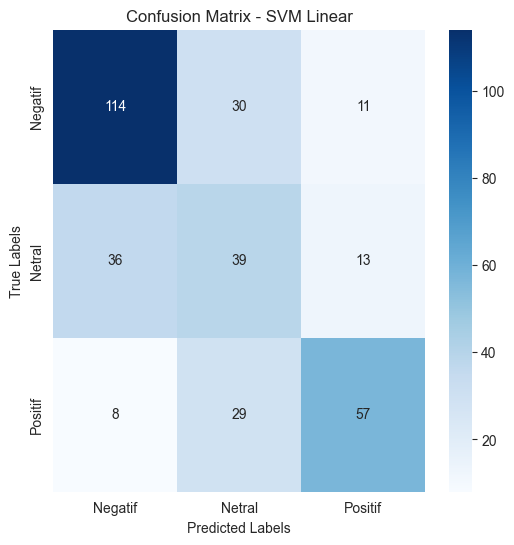

In [43]:
# Menampilkan confusion matrix dalam angka
conf_matrix = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(conf_matrix)

# Fungsi untuk plot confusion matrix
def plot_confusion_matrix(model_name, y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 6))
    
    # Dapatkan label unik dari data
    labels = sorted(set(list(y_true) + list(y_pred)))
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True, 
                xticklabels=labels, yticklabels=labels)
    plt.title(f'Confusion Matrix - {model_name}')
    plt.xlabel('Predicted Labels')
    plt.ylabel('True Labels')
    plt.show()

plot_confusion_matrix('SVM Linear', y_test, y_pred)

In [44]:
# Menampilkan accuracy untuk SVM
accuracy_svm = accuracy_score(y_test, y_pred)
print("SVM Accuracy:", accuracy_svm)
print("")

accuracy_svm_percentage = accuracy_svm * 100
print("SVM Accuracy: {:.2f}%".format(accuracy_svm_percentage))
print("")

# Menampilkan classification report untuk SVM
print("SVM Classification Report:")
print(classification_report(y_test, y_pred))

SVM Accuracy: 0.6231454005934718

SVM Accuracy: 62.31%

SVM Classification Report:
              precision    recall  f1-score   support

     Negatif       0.72      0.74      0.73       155
      Netral       0.40      0.44      0.42        88
     Positif       0.70      0.61      0.65        94

    accuracy                           0.62       337
   macro avg       0.61      0.60      0.60       337
weighted avg       0.63      0.62      0.63       337




PERBANDINGAN KERNEL SVM: LINEAR vs RBF

✅ SVM Linear Accuracy:  0.6231 (62.31%)
✅ SVM RBF Accuracy:     0.6409 (64.09%)
📊 Selisih: 0.0178


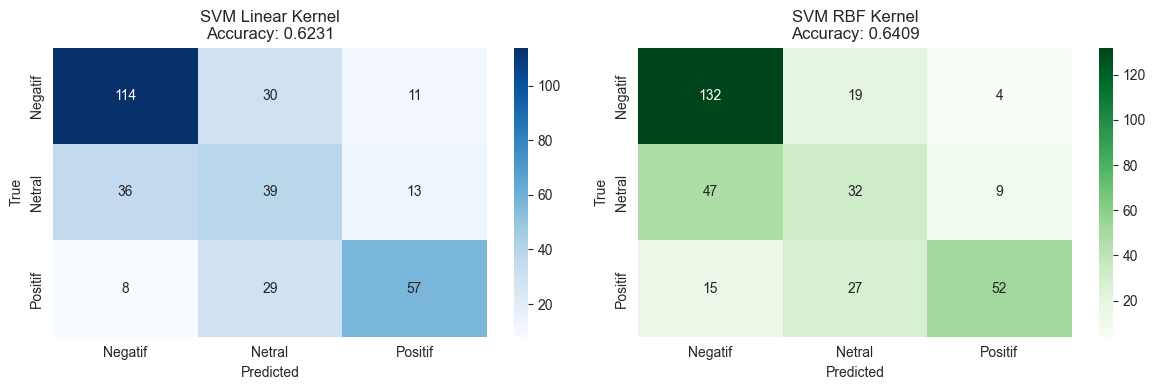


📋 Classification Report - SVM RBF Kernel:
              precision    recall  f1-score   support

     Negatif       0.68      0.85      0.76       155
      Netral       0.41      0.36      0.39        88
     Positif       0.80      0.55      0.65        94

    accuracy                           0.64       337
   macro avg       0.63      0.59      0.60       337
weighted avg       0.64      0.64      0.63       337



In [45]:
# ===== KERNEL COMPARISON: LINEAR vs RBF =====
from sklearn.svm import SVC
import matplotlib.pyplot as plt

print("\n" + "="*60)
print("PERBANDINGAN KERNEL SVM: LINEAR vs RBF")
print("="*60)

# Train SVM dengan kernel RBF
svm_rbf = SVC(kernel='rbf', gamma='scale', C=1.0)
svm_rbf.fit(X_train_vectorized, y_train)
y_pred_rbf = svm_rbf.predict(X_test_vectorized)

# Bandingkan accuracy
accuracy_linear = accuracy_score(y_test, y_pred)
accuracy_rbf = accuracy_score(y_test, y_pred_rbf)

print(f"\n✅ SVM Linear Accuracy:  {accuracy_linear:.4f} ({accuracy_linear*100:.2f}%)")
print(f"✅ SVM RBF Accuracy:     {accuracy_rbf:.4f} ({accuracy_rbf*100:.2f}%)")
print(f"📊 Selisih: {abs(accuracy_linear - accuracy_rbf):.4f}")

# Plot comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Linear
cm_linear = confusion_matrix(y_test, y_pred)
sns.heatmap(cm_linear, annot=True, fmt='d', cmap='Blues', ax=axes[0], cbar=True,
            xticklabels=sorted(set(list(y_test) + list(y_pred))),
            yticklabels=sorted(set(list(y_test) + list(y_pred))))
axes[0].set_title(f'SVM Linear Kernel\nAccuracy: {accuracy_linear:.4f}')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')

# RBF
cm_rbf = confusion_matrix(y_test, y_pred_rbf)
sns.heatmap(cm_rbf, annot=True, fmt='d', cmap='Greens', ax=axes[1], cbar=True,
            xticklabels=sorted(set(list(y_test) + list(y_pred_rbf))),
            yticklabels=sorted(set(list(y_test) + list(y_pred_rbf))))
axes[1].set_title(f'SVM RBF Kernel\nAccuracy: {accuracy_rbf:.4f}')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('True')

plt.tight_layout()
plt.show()

# Classification Report untuk RBF
print("\n📋 Classification Report - SVM RBF Kernel:")
print(classification_report(y_test, y_pred_rbf))


HYPERPARAMETER TUNING: GridSearchCV

🔍 Melakukan GridSearchCV dengan parameter grid:
   C: [0.1, 1, 10, 100]
   Gamma: ['scale', 'auto', 0.001, 0.01, 0.1, 1]
   Kernel: ['linear', 'rbf']
   (Kombinasi total: 4 × 6 × 2 = 48 model)

✅ Tuning selesai dalam 16.86 detik

🏆 Best Parameters: {'C': 1, 'gamma': 'scale', 'kernel': 'linear'}
🏆 Best CV Accuracy: 0.6446

📊 Best Model Test Accuracy: 0.6231 (62.31%)

RINGKASAN PERBANDINGAN MODEL
SVM Linear (Original):        0.6231
SVM RBF (Original):           0.6409
SVM Tuned (GridSearchCV):     0.6231

✨ Model Terbaik: RBF

📋 Classification Report - SVM Tuned Model:
              precision    recall  f1-score   support

     Negatif       0.72      0.74      0.73       155
      Netral       0.40      0.44      0.42        88
     Positif       0.70      0.61      0.65        94

    accuracy                           0.62       337
   macro avg       0.61      0.60      0.60       337
weighted avg       0.63      0.62      0.63       337



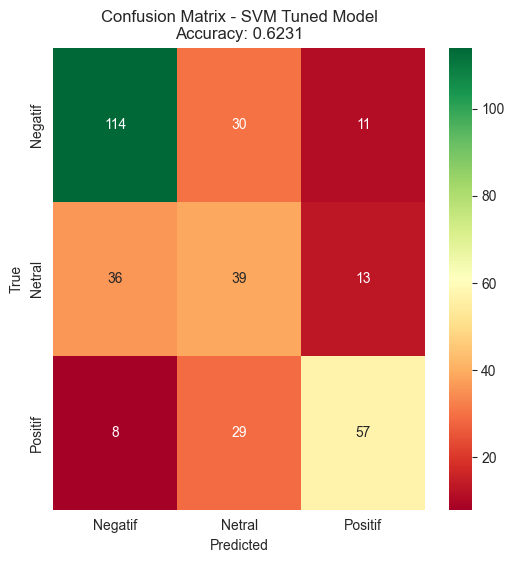

In [46]:
# ===== HYPERPARAMETER TUNING dengan GridSearchCV =====
from sklearn.model_selection import GridSearchCV
import time

print("\n" + "="*60)
print("HYPERPARAMETER TUNING: GridSearchCV")
print("="*60)

# Define parameter grid untuk tuning
# Untuk Linear Kernel: tune parameter C
# Untuk RBF Kernel: tune C dan Gamma
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.001, 0.01, 0.1, 1],
    'kernel': ['linear', 'rbf']
}

print("\n🔍 Melakukan GridSearchCV dengan parameter grid:")
print(f"   C: {param_grid['C']}")
print(f"   Gamma: {param_grid['gamma']}")
print(f"   Kernel: {param_grid['kernel']}")
print("   (Kombinasi total: 4 × 6 × 2 = 48 model)")

# GridSearchCV dengan cv=5 (5-fold cross-validation)
start_time = time.time()
grid_search = GridSearchCV(SVC(), param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=0)
grid_search.fit(X_train_vectorized, y_train)
elapsed = time.time() - start_time

# Best parameters
print(f"\n✅ Tuning selesai dalam {elapsed:.2f} detik")
print(f"\n🏆 Best Parameters: {grid_search.best_params_}")
print(f"🏆 Best CV Accuracy: {grid_search.best_score_:.4f}")

# Evaluate best model pada test set
y_pred_tuned = grid_search.predict(X_test_vectorized)
accuracy_tuned = accuracy_score(y_test, y_pred_tuned)

print(f"\n📊 Best Model Test Accuracy: {accuracy_tuned:.4f} ({accuracy_tuned*100:.2f}%)")

# Comparison: Original Linear vs Tuned Model
print("\n" + "="*60)
print("RINGKASAN PERBANDINGAN MODEL")
print("="*60)
print(f"SVM Linear (Original):        {accuracy_linear:.4f}")
print(f"SVM RBF (Original):           {accuracy_rbf:.4f}")
print(f"SVM Tuned (GridSearchCV):     {accuracy_tuned:.4f}")
best_model = "Tuned Model" if accuracy_tuned >= max(accuracy_linear, accuracy_rbf) else "Linear" if accuracy_linear > accuracy_rbf else "RBF"
print(f"\n✨ Model Terbaik: {best_model}")

# Confusion Matrix untuk Tuned Model
print("\n📋 Classification Report - SVM Tuned Model:")
print(classification_report(y_test, y_pred_tuned))

cm_tuned = confusion_matrix(y_test, y_pred_tuned)
plt.figure(figsize=(6, 6))
sns.heatmap(cm_tuned, annot=True, fmt='d', cmap='RdYlGn', cbar=True,
            xticklabels=sorted(set(list(y_test) + list(y_pred_tuned))),
            yticklabels=sorted(set(list(y_test) + list(y_pred_tuned))))
plt.title(f'Confusion Matrix - SVM Tuned Model\nAccuracy: {accuracy_tuned:.4f}')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

In [47]:
# ===== ERROR ANALYSIS: Analisis Prediksi Salah =====
import pandas as pd

print("\n" + "="*80)
print("ERROR ANALYSIS: Mengapa Model Salah Memprediksi?")
print("="*80)

# Create dataframe dengan hasil prediksi
test_results = pd.DataFrame({
    'original_text': X_test.values,
    'stemmed_text': X_test.values,
    'true_label': y_test.values,
    'predicted_label': y_pred_tuned,
    'is_correct': y_test.values == y_pred_tuned
})

# Filter prediksi yang salah
wrong_predictions = test_results[~test_results['is_correct']]

print(f"\n📊 Total Test Samples: {len(test_results)}")
print(f"✅ Correct Predictions: {sum(test_results['is_correct'])} ({sum(test_results['is_correct'])/len(test_results)*100:.2f}%)")
print(f"❌ Wrong Predictions: {len(wrong_predictions)} ({len(wrong_predictions)/len(test_results)*100:.2f}%)")

if len(wrong_predictions) > 0:
    print(f"\n{'='*80}")
    print("CONTOH PREDIKSI SALAH (5 Contoh Pertama):")
    print(f"{'='*80}")
    
    for idx, (i, row) in enumerate(wrong_predictions.head(5).iterrows()):
        print(f"\n🔴 Contoh {idx+1}:")
        print(f"   Original Text: {df.loc[X_test.index[test_results.index.tolist().index(i)], 'ulasan'][:150]}...")
        print(f"   Clean Text: {row['original_text'][:100]}...")
        print(f"   True Label: {row['true_label']} | Predicted: {row['predicted_label']}")
        
        # Analisis mengapa salah
        print(f"   🔍 Analisis Kesalahan:")
        text_lower = row['original_text'].lower()
        
        # Cek kata-kata kunci
        pos_keywords = ['bagus','suka','mantap','keren','baik','terima kasih','love','recommended','oke','happy']
        neg_keywords = ['lag','ngelag','bug','jelek','buruk','rusak','kecewa','force close','stuck','freeze','lemot','error']
        
        pos_found = [k for k in pos_keywords if k in text_lower]
        neg_found = [k for k in neg_keywords if k in text_lower]
        
        if pos_found:
            print(f"       - Kata Positif ditemukan: {pos_found}")
        if neg_found:
            print(f"       - Kata Negatif ditemukan: {neg_found}")
        
        if not pos_found and not neg_found:
            print(f"       - Tidak ada kata-kata kunci utama → Ambiguitas, mungkin Sentimen Netral atau Campuran")
        elif len(pos_found) > 0 and len(neg_found) > 0:
            print(f"       - Sentimen Campuran (Positif & Negatif) → Sulit diklasifikasi")
        elif row['true_label'] != row['predicted_label']:
            if len(pos_found) > len(neg_found) and row['true_label'] == 'Negatif':
                print(f"       - Model melihat kata positif lebih banyak, tapi sebenarnya Negatif (Mungkin sarkasme?)")
            elif len(neg_found) > len(pos_found) and row['true_label'] == 'Positif':
                print(f"       - Model melihat kata negatif lebih banyak, tapi sebenarnya Positif (Komplain dengan ending positif?)")
else:
    print("\n✅ Semua prediksi benar! Tidak ada kesalahan yang ditemukan.")


ERROR ANALYSIS: Mengapa Model Salah Memprediksi?

📊 Total Test Samples: 337
✅ Correct Predictions: 210 (62.31%)
❌ Wrong Predictions: 127 (37.69%)

CONTOH PREDIKSI SALAH (5 Contoh Pertama):

🔴 Contoh 1:
   Original Text: masa saya pake scrip aja di ban 1 hari, kan niat saya untuk membuat grafik game nya lebih keren, untuk menambah minat bermain tetapi malah di ban, man...
   Clean Text: masa pake scrip aja ban hari kan niat buat grafik game nya lebih keren untuk tambah minat main malah...
   True Label: Positif | Predicted: Negatif
   🔍 Analisis Kesalahan:
       - Kata Positif ditemukan: ['keren']

🔴 Contoh 2:
   Original Text: Makin lama makin ancur game lu, main clasic ataupun Rank, tim-nya gak sepadan.. masa Solo mythic Glory ketemu-nya Legend??? ngotak dikitlah, masalah m...
   Clean Text: makin lama makin ancur game lu main clasic atau rank tim nya gak padan masa solo mythic glory ketemu...
   True Label: Positif | Predicted: Netral
   🔍 Analisis Kesalahan:
       - Kata Positif 

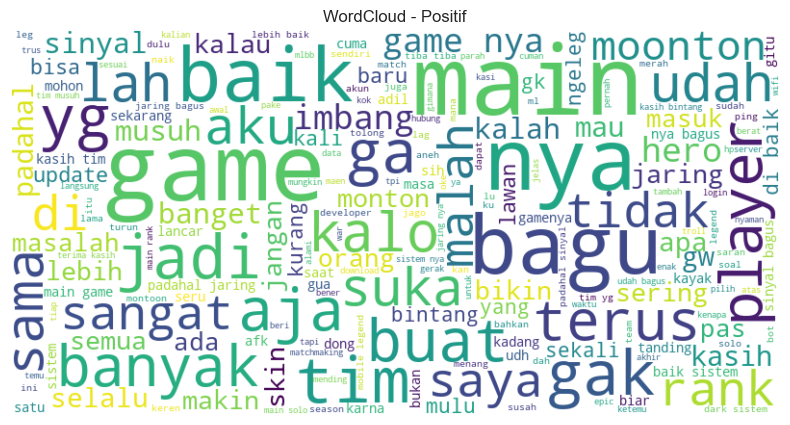

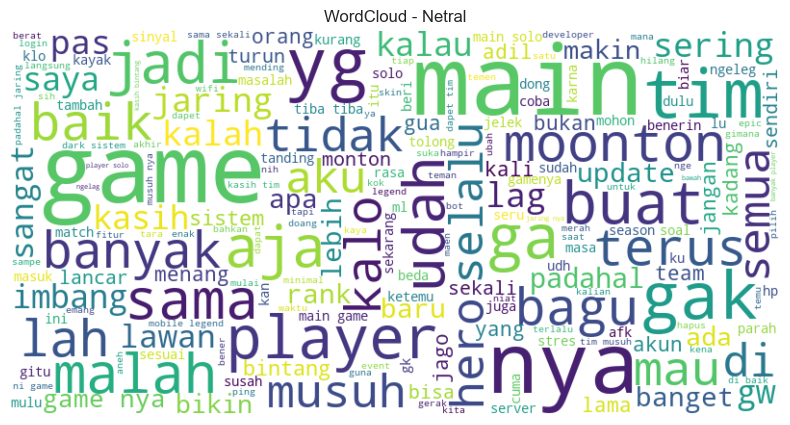

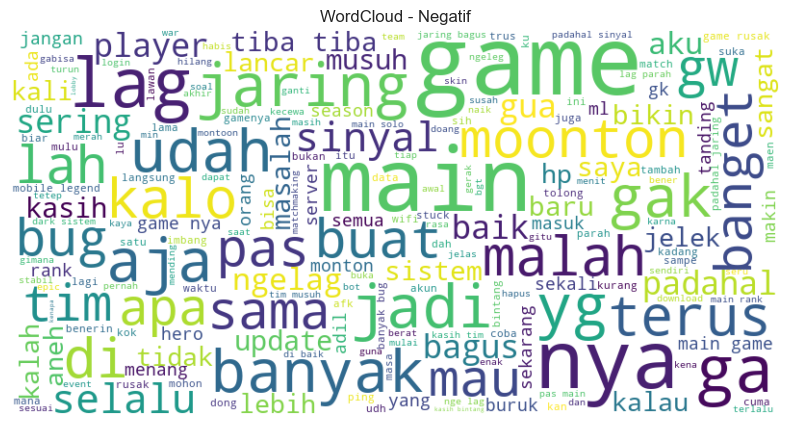

In [48]:
import pandas as pd
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Pisahkan dataset berdasarkan sentimen
sentimen_classes = df['Sentiment'].unique()

# Fungsi untuk membuat dan menampilkan WordCloud
def create_wordcloud(text, title):
    if not text or len(text.strip()) == 0:
        print(f"Tidak ada text untuk {title}")
        return
    
    wordcloud = WordCloud(width=800, height=400, random_state=42,
                         max_font_size=100, background_color='white').generate(text)
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation="bilinear")
    plt.axis('off')
    plt.title(title)
    plt.show()

# Generate WordCloud untuk setiap sentimen
for sentimen in sentimen_classes:
    text_sentimen = df[df['Sentiment'] == sentimen]['stemming_data'].str.cat(sep=' ')
    create_wordcloud(text_sentimen, f'WordCloud - {sentimen}')